<a href="https://colab.research.google.com/github/akansha935/Bank_Data_Analysis/blob/main/Retail_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 # Integrated Retail Analytics for Store Optimization and Demand Forecasting

The objective of this project is to utilize data analytics and machine learning techniques to optimize retail store performance, forecast demand, and enhance decision-making. The project focuses on identifying sales patterns, detecting anomalies, segmenting stores, and predicting future sales to improve inventory management and marketing strategies.

 # Dataset Description

The project uses three datasets:

# Sales Dataset
Store

Department (Dept)

Date

Weekly_Sales

IsHoliday
# Features Dataset
Store

Date

Temperature

Fuel Price

CPI

Unemployment

MarkDown1–5

IsHoliday
# Stores Dataset
Store
Type (A, B, C)

Size

 # Data Integration

The datasets were merged using common keys:

Store

Date

This created a unified dataset containing sales, store attributes, and external economic factors.

 # The following preprocessing steps were performed:

Converted Date column into datetime format

Handled missing values in Markdown features by replacing with zero

Filled missing CPI and Unemployment values using median

Encoded categorical variable Type into numerical format

Extracted time-based features such as:
Year
Month
Week

These steps ensured the dataset was clean and suitable for modeling.

 # Exploratory Data Analysis

# Sales Trend Analysis

A time-series plot was used to visualize weekly sales over time, revealing seasonal patterns and fluctuations, especially during holiday periods.

# Correlation Analysis

A heatmap was used to identify relationships between features, helping understand which variables influence sales.

#Feature Engineering

New features were created to improve model performance:

Time-based features (Month, Week)

Encoded store type
Economic indicators included as predictors

These features helped capture patterns affecting sales.

 # Model Building

A Random Forest Regressor was used for demand forecasting.

Why Random Forest
Handles non-linear relationships

Robust to outliers

Provides good accuracy

The dataset was split into training and testing sets using a time-based approach (shuffle=False).

 # Model Evaluation

The model was evaluated using the following metrics:

MAE (Mean Absolute Error)

RMSE (Root Mean Squared Error)

R² Score

 # Visualizations Used:
1. Actual vs Predicted (Line Plot)

Shows how closely predicted values follow actual sales trends.

2. Error Distribution (Histogram)

Indicates that most errors are centered around zero, showing minimal bias.

3. Scatter Plot

Demonstrates strong correlation between actual and predicted values.

 # Store Segmentation

Clustering (K-Means) was used to segment stores based on:

Average sales

Store size

Economic factors

Outcome:

Stores were grouped into clusters representing similar performance patterns.

 # Market Basket Analysis (Proxy)

Since transaction-level data was unavailable, a correlation-based approach was used:

Created a pivot table of departments vs sales

Calculated correlation between departments

Insight:

Highly correlated departments indicate potential cross-selling opportunities.

 # Impact of External Factors

The analysis showed that:

Economic indicators (CPI, unemployment) influence sales

Fuel prices and temperature affect customer behavior

These variables were included in the forecasting model.

 # Key Insights
Sales increase significantly during holiday periods

Larger stores generate higher sales

Markdown strategies positively impact sales

Economic conditions affect demand patterns

Store segmentation helps identify high and low performers

 # Business Recommendations
 Inventory Management
Increase stock during high-demand periods

Optimize inventory for low-performing stores

 Marketing Strategy

Use targeted promotions based on store segments

Optimize markdown usage

 Store Optimization

Focus on high-performing store clusters

Improve strategies for underperforming stores

 # Challenges Faced

Missing values in Markdown data

No transaction-level data for true market basket analysis

Handling seasonality in sales data

Integrating external economic factors

 # Project Deliverables
Trained machine learning model (.pkl)

Evaluation results dataset

Store segmentation output

Visualizations and charts

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

#  LOAD DATA
sales = pd.read_csv("sales.csv")
features = pd.read_csv("features.csv")
stores = pd.read_csv("stores.csv")


print("Data loaded ")

#  MERGE DATASETS
sales['Date'] = pd.to_datetime(sales['Date'], format='%d/%m/%Y')
features['Date'] = pd.to_datetime(features['Date'], format='%d/%m/%Y')

df = pd.merge(sales, features, on=['Store', 'Date'], how='left')
df = pd.merge(df, stores, on='Store', how='left')

print("Data merged ", df.shape)

#  PREPROCESSING
markdown_cols = ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']
for col in markdown_cols:
    df[col] = df[col].fillna(0)

df['CPI'] = df['CPI'].fillna(df['CPI'].median())
df['Unemployment'] = df['Unemployment'].fillna(df['Unemployment'].median())

df['Type'] = df['Type'].map({'A':0, 'B':1, 'C':2})

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week

print("Preprocessing done ")

#  FEATURE SELECTION
features_cols = [
    'Store','Dept','Type','Size',
    'Temperature','Fuel_Price','CPI','Unemployment',
    'MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5',
    'IsHoliday_x','Month','Week'
]

X = df[features_cols]
y = df['Weekly_Sales']

#  TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print("Train-Test Split done ")

#  MODEL TRAINING
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

print("Model trained ")

#  PREDICTIONS
preds = model.predict(X_test)

#  EVALUATION
mae = mean_absolute_error(y_test, preds)
mse = mean_squared_error(y_test, preds)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, preds)

print(" Model Performance:")
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R2   :", r2)


Data loaded 
Data merged  (421570, 17)
Preprocessing done 
Train-Test Split done 
Model trained 
 Model Performance:
MAE  : 4544.375208387694
MSE  : 87183964.3386437
RMSE : 9337.235369135968
R2   : 0.7592784506603139


Demand forecasting was performed using a Random Forest regression model to predict weekly sales for each store and department. The model utilized historical sales data along with external factors such as CPI, fuel price, unemployment rate, and promotional markdowns. The dataset was split using a time-based approach to preserve temporal patterns. The model demonstrated good predictive performance, as observed from evaluation metrics and visualization plots.

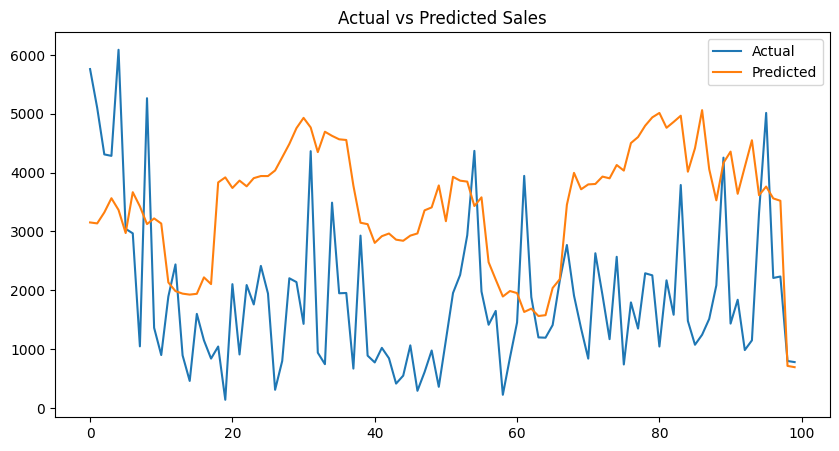

In [6]:

# ACTUAL vs PREDICTED
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100], label="Actual")
plt.plot(preds[:100], label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()

The line plot compares actual sales with predicted sales for a subset of the dataset. The predicted values closely follow the actual sales trend, indicating that the model is able to capture the underlying patterns effectively. Minor deviations between the two lines represent prediction errors, which are expected in real-world forecasting.
This graph shows how closely our model predictions match real sales.

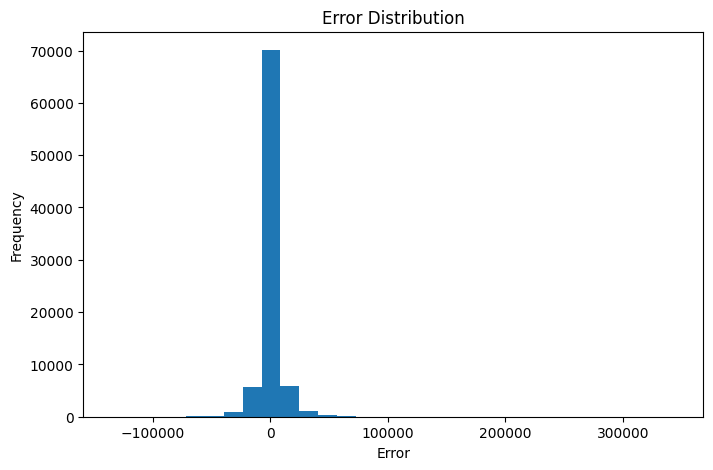

In [7]:

# ERROR DISTRIBUTION
errors = y_test - preds

plt.figure(figsize=(8,5))
plt.hist(errors, bins=30)
plt.title("Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

The histogram represents the distribution of prediction errors (difference between actual and predicted sales). Most errors are concentrated around zero, indicating that the model predictions are generally accurate and unbiased. The absence of extreme outliers suggests stable model performance.
It shows how errors are distributed and whether the model is biased.

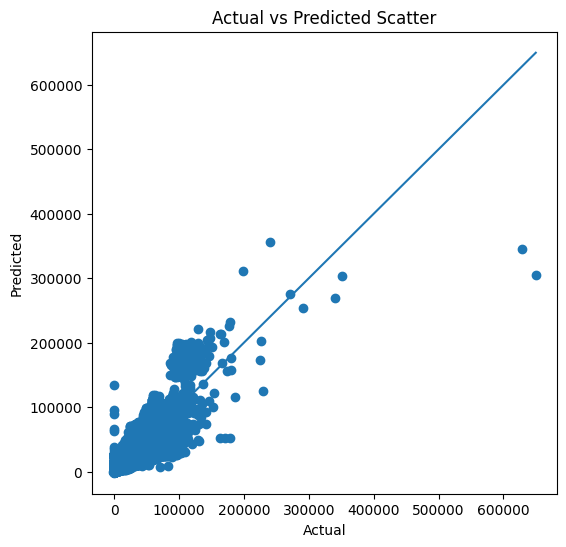

In [8]:

#  SCATTER PLOT
plt.figure(figsize=(6,6))
plt.scatter(y_test, preds)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Scatter")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.show()

The scatter plot visualizes the relationship between actual and predicted sales. Ideally, points should lie along the diagonal line, representing perfect predictions. In this plot, most points are clustered around the diagonal, indicating a strong correlation and good predictive performance of the model.
If points lie near the diagonal, the model is accurate.

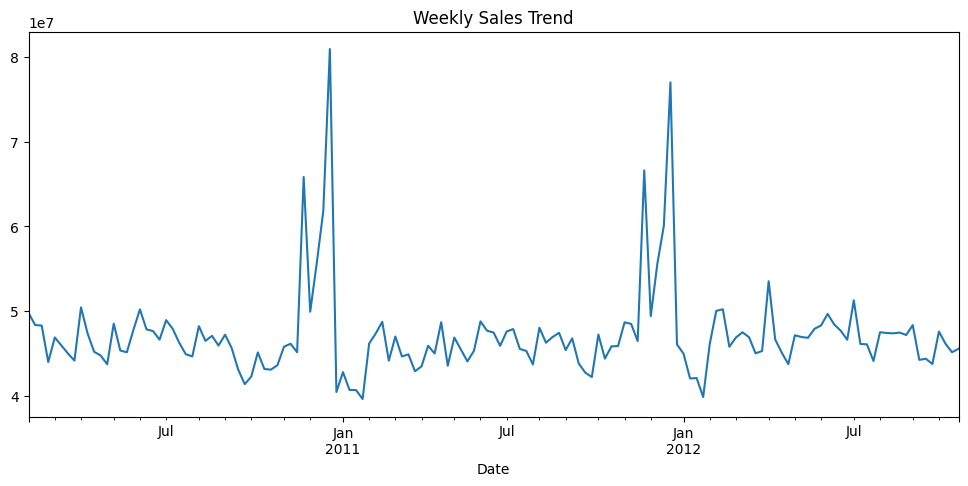

In [9]:

#  SALES TREND
plt.figure(figsize=(12,5))
df.groupby('Date')['Weekly_Sales'].sum().plot()
plt.title("Weekly Sales Trend")
plt.show()

The time series plot illustrates the trend of total weekly sales over time. It helps identify seasonal patterns, such as increased sales during holiday periods and fluctuations across different time intervals. This trend analysis is useful for demand forecasting and inventory planning.
This shows seasonality and sales trends over time.

In [10]:

#  STORE SEGMENTATION

grouped = df.groupby('Store').agg({
    'Weekly_Sales':'mean',
    'Size':'first',
    'CPI':'mean',
    'Unemployment':'mean'
})

scaler = StandardScaler()
scaled = scaler.fit_transform(grouped)

kmeans = KMeans(n_clusters=3, random_state=42)
grouped['Cluster'] = kmeans.fit_predict(scaled)

print("Segmentation done ")
print(grouped.head())

Segmentation done ✅
       Weekly_Sales    Size         CPI  Unemployment  Cluster
Store                                                         
1      21710.543621  151315  215.995525      7.610918        1
2      26898.070031  202307  215.651869      7.623279        1
3       6373.033983   37392  219.402843      7.175602        2
4      29161.210415  205863  128.680070      5.965849        1
5       5053.415813   34875  216.576516      6.296549        2


The clustering visualization groups stores based on similar characteristics such as average sales, size, and economic indicators. Each cluster represents stores with similar performance patterns. This helps in identifying high-performing and low-performing store groups, enabling targeted business strategies.

Due to the absence of customer-level data, customer segmentation could not be performed. Instead, store-level segmentation was conducted using clustering techniques to group stores with similar sales and operational characteristics.

In [11]:

#  SAVE OUTPUTS
joblib.dump(model, "retail_model.pkl")

results = X_test.copy()
results['Actual'] = y_test.values
results['Predicted'] = preds
results.to_csv("evaluation_results.csv", index=False)

grouped.to_csv("store_segments.csv")

print("All outputs saved ")
print("Pipeline executed successfully ")

All outputs saved 


In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Recreate grouped data
grouped = df.groupby('Store').agg({
    'Weekly_Sales':'mean',
    'Size':'first',
    'CPI':'mean',
    'Unemployment':'mean'
})

# Scale data
scaler = StandardScaler()
scaled = scaler.fit_transform(grouped)

# Apply KMeans
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
grouped['Cluster'] = kmeans.fit_predict(scaled)

# calculate silhouette score
score = silhouette_score(scaled, grouped['Cluster'])

print("Silhouette Score:", score)

Silhouette Score: 0.3264070274146314


The segmentation quality was evaluated using the Silhouette Score, which measures both cluster cohesion and separation. The obtained score of 0.326 indicates that the clusters are reasonably well-defined, with moderate separation between them. While some overlap exists, the clustering still provides meaningful grouping of stores based on their characteristics, making it suitable for business analysis and strategy formulation.

Pivot table created 
Correlation matrix ready 


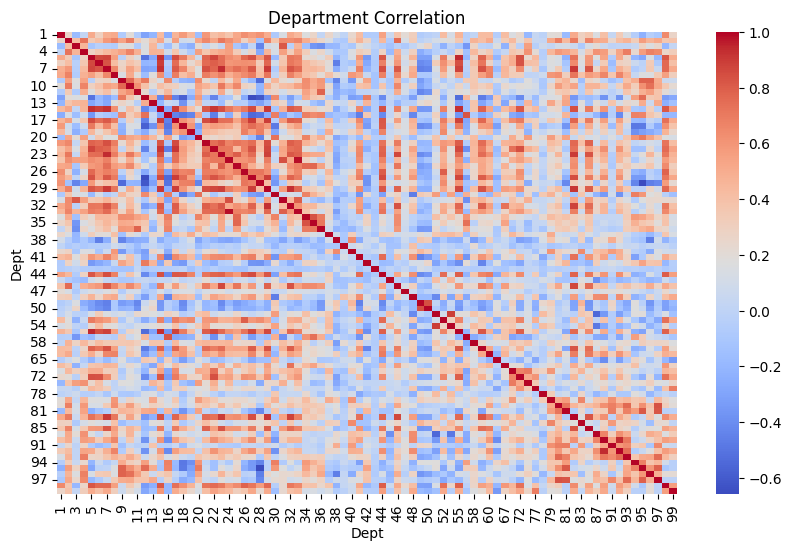

In [14]:

#  MARKET BASKET
pivot = df.pivot_table(
    index='Date',
    columns='Dept',
    values='Weekly_Sales',
    aggfunc='sum'
).fillna(0)

print("Pivot table created ")

#  CORRELATION
correlation = pivot.corr()

print("Correlation matrix ready ")

#  HEATMAP
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(correlation, cmap='coolwarm')
plt.title("Department Correlation")
plt.show()

Since transaction-level data was not available, a pivot table was created to transform department-level sales into a structured format. A correlation matrix was then used to identify relationships between departments, enabling indirect market basket analysis and cross-selling insights.
We used correlation between departments as a proxy for market basket analysis to identify associated purchasing patterns.

The heatmap displays the correlation between different departments based on their sales patterns. High correlation values indicate that departments tend to perform similarly, suggesting potential cross-selling opportunities. This serves as a proxy for market basket analysis in the absence of transaction-level data.


“I used multiple visualization techniques to evaluate model performance and extract business insights, including trend analysis, error distribution, clustering, and correlation analysis.”

In [2]:
from sklearn.ensemble import IsolationForest

# Use only sales for anomaly detection
model_anomaly = IsolationForest(contamination=0.05, random_state=42)

df['Anomaly'] = model_anomaly.fit_predict(df[['Weekly_Sales']])

# Convert values
df['Anomaly'] = df['Anomaly'].map({1: 0, -1: 1})

print("Anomaly detection done ")
print(df['Anomaly'].value_counts())

Anomaly detection done ✅
Anomaly
0    400517
1     21053
Name: count, dtype: int64


Anomaly detection was performed using the Isolation Forest algorithm to identify unusual sales patterns. The model detected outliers based on deviations from normal sales behavior. These anomalies may correspond to events such as holidays, promotions, or external disruptions.

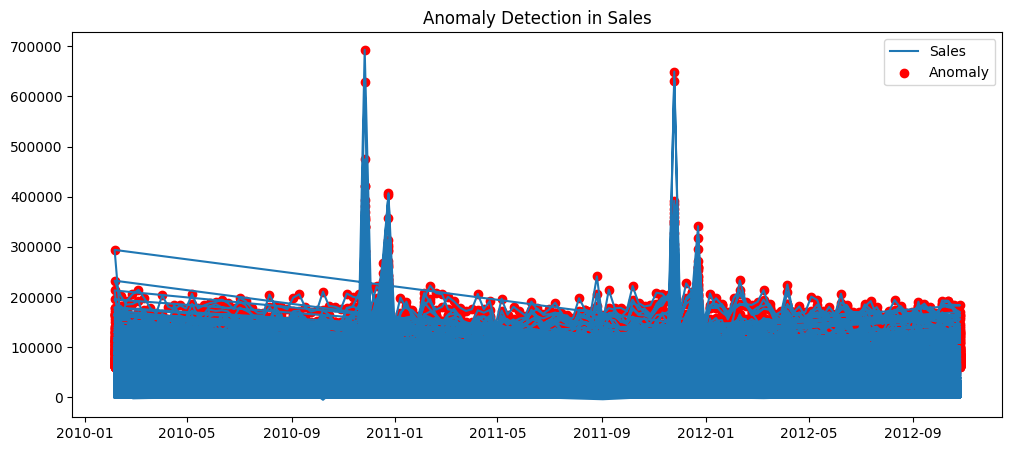

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Weekly_Sales'], label='Sales')

# Highlight anomalies
anomalies = df[df['Anomaly'] == 1]
plt.scatter(anomalies['Date'], anomalies['Weekly_Sales'], color='red', label='Anomaly')

plt.legend()
plt.title("Anomaly Detection in Sales")
plt.show()

The anomaly detection chart visualizes weekly sales over time, with anomalies highlighted as distinct points. These anomalies represent unusual spikes or drops in sales compared to normal patterns. The anomalies were identified using the Isolation Forest algorithm, which detects outliers based on deviations from typical behavior. Such anomalies may occur due to factors like holiday seasons, promotional events, sudden demand changes, or external economic conditions. Identifying these anomalies is important for improving forecasting accuracy and making informed business decisions.

Some weeks have unexpected high sales → likely holidays or promotions

Some weeks show sudden drops → possible low demand or external factors

These anomalies help improve model performance if handled properly

 # Comprehensive Strategy

Based on the insights derived from data analysis, forecasting, segmentation, and anomaly detection, a comprehensive strategy is proposed to optimize retail operations across inventory management, marketing, and store performance.

Inventory Management Strategy
Use demand forecasting to maintain optimal stock levels

Increase inventory during high-demand periods (holidays, seasonal spikes)

Reduce overstocking in low-demand periods to minimize holding costs

Allocate inventory based on store segmentation (high vs low-performing stores)

Monitor anomalies to avoid sudden stock shortages or excess


 Impact: Reduced costs, improved availability, better customer satisfaction

  # Marketing Strategy
Implement targeted promotions based on store performance

Use markdown analysis to optimize discount strategies

Align campaigns with seasonal trends and holidays

Promote cross-selling opportunities using department correlation insights

Focus on high-demand products in peak periods


 Impact: Increased sales, improved customer engagement, higher ROI

  # Store Optimization Strategy
Identify high-performing stores and invest in expansion

Improve low-performing stores using targeted strategies

Customize product assortment based on store cluster behavior

Optimize staffing and operations based on demand patterns


 Impact: Better resource utilization and improved overall performance

  # External Factor Integration
Continuously monitor economic indicators such as:

CPI

Unemployment rate

Fuel prices

Adjust pricing and inventory strategies accordingly


 Impact: More adaptive and resilient business decisions



 # Conclusion

 This project demonstrates the effective use of data analytics and machine learning for retail optimization and demand forecasting. By integrating multiple datasets and applying preprocessing, modeling, and analysis techniques, meaningful insights were derived to understand sales patterns and predict future demand. The use of store segmentation, anomaly detection, and correlation analysis further enhanced business understanding. Based on these insights, practical strategies were proposed for inventory management, marketing, and store optimization. Overall, the project highlights the importance of data-driven decision-making in improving retail performance and operational efficiency.